# Perceptron

Mostraremos una grafica del perceptron usando mermaid, pero como Colab no lo soporta directamente, creamos el grpafico mermaid con la biblioteca mermaidx de python.


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


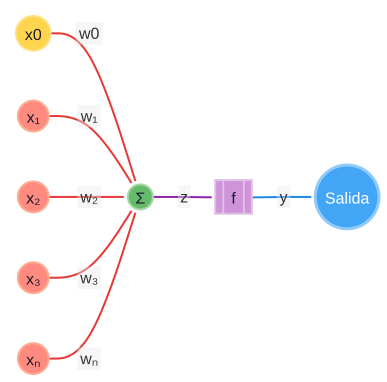

In [1]:
# 1. Instalar la librería mermaidx
!pip install mermaidx -q

# 2. Importar la librería
import mermaidx

# 3. Definir tu diagrama en sintaxis Mermaid
#    (Este es un diagrama de flujo simple)
diagrama_codigo = """
graph LR
    B((x0)) -->|w0| SUM
    X1((x₁)) -->|w₁| SUM((Σ))
    X2((x₂)) -->|w₂| SUM
    X3((x₃)) -->|w₃| SUM
    Xn((xₙ)) -->|wₙ| SUM

    SUM -->|z| ACT[[f]]
    ACT -->|y| Y((Salida))

    style X1 fill:#ff8a80,stroke:#ffab91,stroke-width:2px,color:#1a1a2e
    style X2 fill:#ff8a80,stroke:#ffab91,stroke-width:2px,color:#1a1a2e
    style X3 fill:#ff8a80,stroke:#ffab91,stroke-width:2px,color:#1a1a2e
    style Xn fill:#ff8a80,stroke:#ffab91,stroke-width:2px,color:#1a1a2e
    style SUM fill:#66bb6a,stroke:#a5d6a7,stroke-width:2px,color:#1a1a2e
    style ACT fill:#ce93d8,stroke:#e1bee7,stroke-width:2px,color:#1a1a2e
    style Y fill:#42a5f5,stroke:#90caf9,stroke-width:3px,color:#ffffff
    style B fill:#ffd54f,stroke:#ffe082,stroke-width:2px,color:#1a1a2e
    %% Flechas de entradas (índices 0 a 4) en rojo
    linkStyle 0,1,2,3,4 stroke:#e53935,stroke-width:2px
    %% Flecha SUM -> ACT (índice 5) en morado
    linkStyle 5 stroke:#8e24aa,stroke-width:2px
    %% Flecha ACT -> Salida (índice 6) en azul
    linkStyle 6 stroke:#1e88e5,stroke-width:2px
"""

# 4. Renderizar el diagrama
#
mermaidx.render(diagrama_codigo)

## 1. Arquitectura básica

Para simplificar las matemáticas y la implementación, añadimos el **sesgo** (*bias*) como $w_0$ con una entrada adicional $x_0 = 1$.

De esta forma, el perceptrón recibe **$n+1$ entradas**:

- $x_0 = 1$ (entrada constante)
- $x_1, x_2, \dots, x_n$ (entradas de los datos)

Y sus pesos correspondientes:

- $w_0 = b$ (el sesgo)
- $w_1, w_2, \dots, w_n$ (pesos de las características)

La suma ponderada (potencial de activación) se calcula como:

$$
z = \sum_{i=0}^{n} w_i x_i = w_0 \cdot 1 + \sum_{i=1}^{n} w_i x_i = b + \sum_{i=1}^{n} w_i x_i
$$

Luego, aplicamos la función de activación **escalón** (o *Heaviside*):

$
\hat{y} =
\begin{cases}
1 & \text{si } z \geq 0 \\
0 & \text{si } z < 0
\end{cases}
$

## 2. El error

Para ajustar los pesos, primero calculamos el **error** entre la salida deseada (la etiqueta real $y$) y la salida obtenida $(\hat{y}$):

$
e = y - \hat{y}
$

Los posibles valores del error son:

- **$e = 0$** → La predicción fue correcta.
- **$e = +1$** → $y = 1$ y $\hat{y} = 0$ (Falso negativo, la neurona no se activó cuando debía).
- **$e = -1$** → $y = 0$ y $\hat{y} = 1$ (Falso positivo, la neurona se activó cuando no debía).


## 3. La regla de actualización de pesos (Regla Delta unificada)

Ahora, aplicamos **la misma fórmula** de actualización de pesos a **todos** los pesos, incluyendo el sesgo:

$$
\Delta w_i = \eta \cdot e \cdot x_i
$$

$$
w_i^{\text{nuevo}} = w_i^{\text{viejo}} + \Delta w_i
$$

Donde:
- **$\eta$** (eta) es la **tasa de aprendizaje**.
- **$e$** es el error calculado.
- **$x_i$** es el valor de la entrada i-ésima.

> Como observacion nota que para $i = 0$, como $x_0 = 1$, la actualización del sesgo es:

$$
\Delta w_0 = \eta \cdot e \cdot 1 = \eta \cdot e
$$
$$
b^{\text{nuevo}} = b^{\text{viejo}} + \eta \cdot e
$$

Que es exactamente la misma regla que teníamos cuando tratamos el $bias$ de manera separada, pero ahora forma parte natural de la misma ecuación.

## 4. Lógica intuitiva del ajuste (caso por caso)

Vamos a ver qué hace esta fórmula en cada situación (suponiendo $\eta > 0$):

| Caso | $y$ | $\hat{y}$ | $e$ | Entrada $x_i$ | Efecto sobre $w_i$ |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **Acierto** | 1 | 1 | 0 | Cualquiera | **No se modifica** ($\Delta = 0$) |
| **Acierto** | 0 | 0 | 0 | Cualquiera | **No se modifica** ($\Delta = 0$) |
| **Falso Negativo** | 1 | 0 | **+1** | $x_i$ positiva (+) | **Aumenta** el peso ($w_i$ sube) |
| **Falso Negativo** | 1 | 0 | **+1** | $x_i$ negativa (-) | **Disminuye** el peso ($w_i$ baja) |
| **Falso Negativo** | 1 | 0 | **+1** | $x_0 = 1$ (Sesgo) | **Aumenta** el sesgo ($w_0$ sube) |
| **Falso Positivo** | 0 | 1 | **-1** | $x_i$ positiva (+) | **Disminuye** el peso ($w_i$ baja) |
| **Falso Positivo** | 0 | 1 | **-1** | $x_i$ negativa (-) | **Aumenta** el peso ($w_i$ sube) |
| **Falso Positivo** | 0 | 1 | **-1** | $x_0 = 1$ (Sesgo) | **Disminuye** el sesgo ($w_0$ baja) |


## 5. Algoritmo de entrenamiento completo (paso a paso)

1. Inicializar **todos** los pesos $w_0, w_1, \dots, w_n$ con valores pequeños aleatorios (ej. entre -0.5 y 0.5). Recuerda que $w_0$ es el sesgo.
2. Para cada muestra de entrenamiento $(x, y)$:
   - Asegurarte de que el vector de entrada incluya $x_0 = 1$: $x = [1, x_1, x_2, \dots, x_n]$.
   - Calcular la salida $\hat{y}$ (aplicar el escalón a $z = \sum w_i x_i$).
   - Calcular el error $e = y - \hat{y}$.
   - **Actualizar TODOS los pesos**: $w_i = w_i + \eta \cdot e \cdot x_i$ para $i = 0, 1, \dots, n$.
3. Repetir el paso 2 durante varias **épocas** hasta que todos los ejemplos se clasifiquen correctamente (error 0) o se alcance un número máximo de iteraciones.

## 6. Puntos clave y limitaciones

- **Convergencia**: El teorema de convergencia del perceptrón garantiza que **si los datos son linealmente separables**, el algoritmo encontrará una solución en un número finito de pasos.
- **Tasa de aprendizaje**: Si $\eta$ es muy grande, los pesos oscilarán y no convergerán. Si es muy pequeño, tardará mucho en aprender. Un valor típico es $\eta = 0.1$ o $0.01$.
- **Limitación**: Si los datos **no son linealmente separables** (ej. la función XOR), el perceptrón simple **nunca convergerá** y los pesos seguirán saltando sin encontrar una solución.

## Ejemplo 1 python

Compuerta AND

In [2]:
# entradas de la copuerta
X = [(0,0), (0,1), (1,0), (1,1)]
# salidas
y = [0, 0, 0, 1]

w = [0.0, 0.0] # pesos
b = 0.0 # bias
lr = 0.1 # taza de aprendizaje
epochs = 20 # número de iteraciones

# funcion de activación escalon (step function)
def step(z):
    return 1 if z >= 0 else 0

for epoch in range(epochs):
    errores = 0
    for (x0, x1), yi in zip(X, y):
        z = w[0]*x0 + w[1]*x1 + b
        y_pred = step(z)
        error = yi - y_pred
        if error != 0:
            w[0] += lr * error * x0
            w[1] += lr * error * x1
            b    += lr * error
            errores += 1
    print(f"Época {epoch+1}: errores = {errores}")
    if errores == 0:
        break

print("\nPesos:", w)
print("Bias:", b)

print("\nPredicciones:")
for (x0, x1) in X:
    print(f"({x0}, {x1}) -> {step(w[0]*x0 + w[1]*x1 + b)}")

Época 1: errores = 2
Época 2: errores = 3
Época 3: errores = 3
Época 4: errores = 0

Pesos: [0.2, 0.1]
Bias: -0.20000000000000004

Predicciones:
(0, 0) -> 0
(0, 1) -> 0
(1, 0) -> 0
(1, 1) -> 1


## Ejemplo 2 python

In [ ]:
import numpy as np

# --- Configuración del perceptrón ---
eta = 0.1                     # Tasa de aprendizaje
max_epochs = 10               # Máximo de épocas

# --- Datos de entrenamiento (compuerta AND) ---
X_train = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])
y_train = np.array([0, 0, 0, 1])

# Número de características (sin contar el sesgo)
n_features = X_train.shape[1]

# 1. Inicializar TODOS los pesos (w_0, w_1, ..., w_n) con valores pequeños aleatorios entre -0.5 y 0.5.
# np.random.uniform(low=0.0, high=1.0, size=None)
# low: límite inferior (incluido).
# high: límite superior (excluido en la práctica).,
# size: forma del array de salida.
# El índice 0 es el sesgo (w_0), los demás son pesos de las características.
weights = np.random.uniform(-0.5, 0.5, size=n_features + 1)

# Función de activación escalón
def step_activation(z):
    return 1 if z >= 0 else 0

# Función para predecir una sola muestra (con sesgo incluido)
# esta funci´´on recibe algo como [0, 1] o [1, 1]
def predict(x):
    # Agregar el sesgo: [1, x1, x2, ...]
    # inserta 1 en la posición 0 del vector x,
    # Si x = [x1, x2], el resultado es [1, x1, x2]
    x_with_bias = np.insert(x, 0, 1)
    # Calcula el producto punto entre el vector de pesos y el vector de entrada con sesgo. Es decir, la suma ponderada:
    # z=w_0⋅1+w_1⋅x1+w_2⋅x_2
    z = np.dot(weights, x_with_bias)
    return step_activation(z)

# --- Entrenamiento ---
for epoch in range(max_epochs):
    total_errors = 0

    # 2. Para cada muestra de entrenamiento
    # zip(X_train, y_train) empareja elmento a lemento los 2 arrays
    # X_train matriz de entradas (4 filas × 2 columnas).
    # y_train Vector de salidas esperadas (4 valores: 0, 0, 0, 1).
    # xi Variable que guardará cada muestra de entrada (un vector como [0, 1]).
    # target Variable que guardará la etiqueta correcta correspondiente a esa muestra.
    for xi, target in zip(X_train, y_train):
        # 2a. Agregar el x_i del Bias, x_0 = 1
        # np.insert(arr, obj, values, axis=None)
        # en el arreglo arr, en la posicion obj=0 inserta 1
        x_with_bias = np.insert(xi, 0, 1)

        # 2b. Calcular la salida (suma ponderada + escalón)
        # producto punto
        # suponga pesos weigths = [0.2, -0.4, 0.3]
        # y x_with_bias = [1, 1, 1]
        # entonces: z = np.dot(weights, x_with_bias)
        # equivale a:
        # z = (0.2 * 1) + (-0.4 * 1) + (0.3 * 1) = 0.2 - 0.4 + 0.3 = 0.1
        z = np.dot(weights, x_with_bias)
        y_hat = step_activation(z)

        # 2c. Calcular el error
        error = target - y_hat

        # 2d. Actualizar TODOS los pesos: w_i = w_i + eta * error * x_i
        weights = weights + eta * error * x_with_bias

        # Acumular el error absoluto para saber si hay fallos
        total_errors += abs(error)

    # Si el error total es 0, todos los ejemplos se clasificaron correctamente
    if total_errors == 0:
        print(f"Convergencia alcanzada en la época {epoch + 1}")
        break

print(f"Entrenamiento finalizado. Pesos finales: {weights}")

# --- Prueba de predicciones ---
print("\n--- Predicciones finales ---")
for xi in X_train:
    pred = predict(xi)
    print(f"Entrada: {xi} -> Predicción: {pred}")